# Reproducibility: All Paper Figures

This notebook reproduces every figure and table from:

> Kalmykov et al., *DCT Basis Benchmarks for Neural Image Compression: Revealing Frequency-Dependent Biases*, IEEE Signal Processing Letters, 2026.

## Parameter Reference

| Figure | Script / source | DCT size | Codec settings |
|--------|----------------|----------|----------------|
| Fig. 1 | `plot_hero_figure.py` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2a | `make_paper_figures.py` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2b | `make_paper_figures.py` | 128 | `cheng2020-anchor`, q=6 |
| Fig. 2c | `make_paper_figures.py` | 128 | fine-tuned `cheng2020-anchor`, q=6 |
| Fig. 3 | `plot_fig3_dct_grid.py` | **256** | q=1 (low) and q=6 (high); TCM: p=64/128; JPEG/WebP: q=20/95; JXL: d=4.0/0.6 |
| Fig. 4a | `plot_cheng_scale.py` | 64–1024 | `cheng2020-anchor/attn`, q=1–6 |
| Fig. 4b | — | **1024** | `cheng2020-anchor`, q=6 (artifact) |
| Fig. 5 | `plot_leakage_vs_bpp.py` | **256** | all q levels (rate sweep) |
| Fig. S1 | `run_directional.py` | **512** | matched ≈2.5 bpp; JPEG q=43, WebP q=70, JXL d=2.5 |
| Fig. S2 | `plot_distortion_consistency_paper.py` | 512 | `cheng2020-anchor`, q=6; Gaussian noise σ∈[0.01,0.2] |
| Fig. S3 | `run_finetune.py` | **1024** | `cheng2020-anchor`, q=6, 900 steps |
| Table I | `run_kodak_eval.py` | **512** | all codecs, highest quality, 24 Kodak images |

Outputs are saved to `paper/figures/`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch
from pathlib import Path

from dct_nic import evaluate_codec, load_model, build_dct_basis_rgb
from dct_nic.metrics import all_metrics, compute_response_matrix

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS = Path('../results')
OUT = Path('../paper/figures')
OUT.mkdir(parents=True, exist_ok=True)

# Shared style constants (IEEE SPL)
plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'mathtext.fontset': 'cm'})

COLORS = {
    'cheng2020-anchor': '#7E489E', 'cheng2020-attn': '#E883B6',
    'mbt2018-mean': '#717171', 'mbt2018': '#A0BBD4',
    'bmshj2018-hyperprior': '#B8B028', 'bmshj2018-factorized': '#7B4B3D',
    'ftic': '#D82F30', 'tcm': '#F0801F',
    'jpeg': '#287BB8', 'webp': '#429A38', 'jpegxl': '#3AC1CF',
}
MARKERS = {
    'cheng2020-anchor': 's', 'cheng2020-attn': 'D',
    'mbt2018-mean': 'o', 'mbt2018': 'P',
    'bmshj2018-hyperprior': 'p', 'bmshj2018-factorized': '^',
    'ftic': 'h', 'tcm': 'X',
    'jpeg': '*', 'webp': 'v', 'jpegxl': 'd',
}
LABELS = {
    'cheng2020-anchor': 'Cheng2020-Anchor', 'cheng2020-attn': 'Cheng2020-Attention',
    'mbt2018-mean': 'MBT2018-Mean', 'mbt2018': 'MBT2018',
    'bmshj2018-hyperprior': 'BMSHJ2018-Hyperprior', 'bmshj2018-factorized': 'BMSHJ2018-Factorized',
    'ftic': 'FTIC', 'tcm': 'TCM',
    'jpeg': 'JPEG', 'webp': 'WebP', 'jpegxl': 'JPEG XL',
}
TRADITIONAL = {'jpeg', 'webp', 'jpegxl'}

print(f'Device: {DEVICE}  |  Output: {OUT}')

Device: cuda  |  Output: ../paper/figures


---
## Fig. 1 — DCT Basis, Frequency Map, and Codec Reconstruction

**Settings:** `cheng2020-anchor`, q=6, size=**128×128**

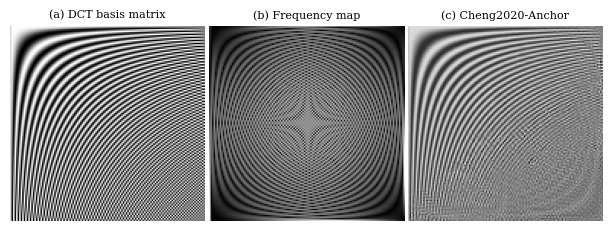

Fig. 1 saved.


In [2]:
# Parameters for Fig. 1
SIZE_FIG1 = 128
MODEL_FIG1 = 'cheng2020-anchor'
Q_FIG1 = 6

model = load_model(MODEL_FIG1, Q_FIG1, DEVICE)
result = evaluate_codec(model, size=SIZE_FIG1, device=DEVICE, model_name=MODEL_FIG1, num_runs=1)

orig = result['orig']   # (128, 128, 3)
recon = result['recon'] # (128, 128, 3)
recon_disp = np.clip((recon - recon.min()) / (recon.max() - recon.min() + 1e-9), 0, 1)

# Diagonal-direction frequency map (gradient magnitude of DCT basis)
from dct_nic import build_dct_basis
D_raw = build_dct_basis(SIZE_FIG1)
gy, gx = np.gradient(D_raw)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(6, 2.2))
axes[0].imshow(orig.mean(axis=2), cmap='gray'); axes[0].axis('off')
axes[0].set_title('(a) DCT basis matrix', fontsize=8)
axes[1].imshow(freq_map, cmap='gray'); axes[1].axis('off')
axes[1].set_title('(b) Frequency map', fontsize=8)
axes[2].imshow(recon_disp.mean(axis=2), cmap='gray'); axes[2].axis('off')
axes[2].set_title('(c) Cheng2020-Anchor', fontsize=8)
plt.tight_layout(pad=0.3)
plt.savefig(OUT / 'fig1.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Fig. 1 saved.')

---
## Fig. 2 — Frequency-Response Matrix, Metrics, and Fine-Tuning

**Settings:** `cheng2020-anchor`, q=6, size=**128×128**

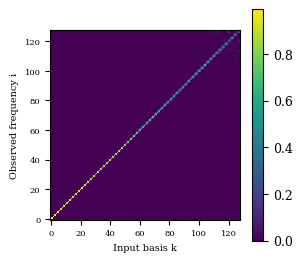

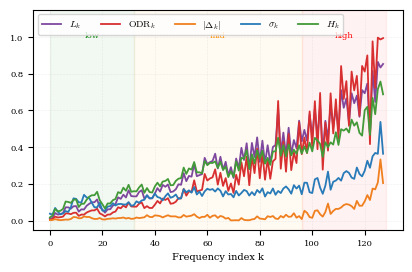

Fig. 2a, 2b saved. Run scripts/run_finetune.py --size 128 for Fig. 2c.


In [3]:
# Re-use result from Fig. 1 (same settings)
R = result['R']
k = np.arange(SIZE_FIG1)

# --- Fig. 2a: Response matrix ---
fig_a, ax_a = plt.subplots(figsize=(2.9, 2.9))
im = ax_a.imshow(R, origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=ax_a, shrink=0.85)
ax_a.set_xlabel('Input basis k', fontsize=7)
ax_a.set_ylabel('Observed frequency i', fontsize=7)
ax_a.tick_params(labelsize=6)
fig_a.tight_layout(pad=0.3)
fig_a.savefig(OUT / 'fig2a_response_matrix.pdf', bbox_inches='tight')
plt.show()

# --- Fig. 2b: Metric curves ---
fig_b, ax_b = plt.subplots(figsize=(4.0, 2.6))
n4 = SIZE_FIG1 // 4
for name, values, color in [
    (r'$L_k$',          result['leakage'],                   '#7E489E'),
    (r'$\mathrm{ODR}_k$', result['odr'],                     '#D82F30'),
    (r'$|\Delta_k|$',   np.abs(result['centroid_shift']),    '#F0801F'),
    (r'$\sigma_k$',     result['spread'],                    '#287BB8'),
    (r'$H_k$',          result['entropy'],                   '#429A38'),
]:
    ax_b.plot(k, values, lw=1.3, color=color, label=name)
ax_b.axvspan(0, n4, alpha=0.05, color='green'); ax_b.text(n4//2, 1.0, 'low', ha='center', fontsize=6, color='green')
ax_b.axvspan(n4, 3*n4, alpha=0.05, color='orange'); ax_b.text(n4 + n4, 1.0, 'mid', ha='center', fontsize=6, color='darkorange')
ax_b.axvspan(3*n4, SIZE_FIG1, alpha=0.05, color='red'); ax_b.text(3*n4 + n4//2, 1.0, 'high', ha='center', fontsize=6, color='red')
ax_b.set_xlabel('Frequency index k', fontsize=7)
ax_b.set_ylim(-0.05, 1.15)
ax_b.legend(fontsize=7, ncol=5, loc='upper left')
ax_b.grid(True, ls=':', lw=0.4, alpha=0.4)
ax_b.tick_params(labelsize=6)
fig_b.tight_layout(pad=0.3)
fig_b.savefig(OUT / 'fig2b_metrics.pdf', bbox_inches='tight')
plt.show()

print('Fig. 2a, 2b saved. Run scripts/run_finetune.py --size 128 for Fig. 2c.')

---
## Fig. 3 — DCT-Basis Response Grid (All Codecs)

**Settings:** size=**256×256**, low quality (q=1 / native low) and high quality (q=6 / native high)

> This figure requires pre-computed reconstructed images in `results/`. Run `scripts/run_benchmark.py --size 256 --quality-sweep` first, or use the pre-computed CSV for metric annotations.

Available models: ['ftic', 'tcm', 'cheng2020-anchor', 'cheng2020-attn', 'bmshj2018-factorized', 'bmshj2018-hyperprior', 'mbt2018-mean', 'mbt2018', 'jpegxl', 'jpeg', 'webp']


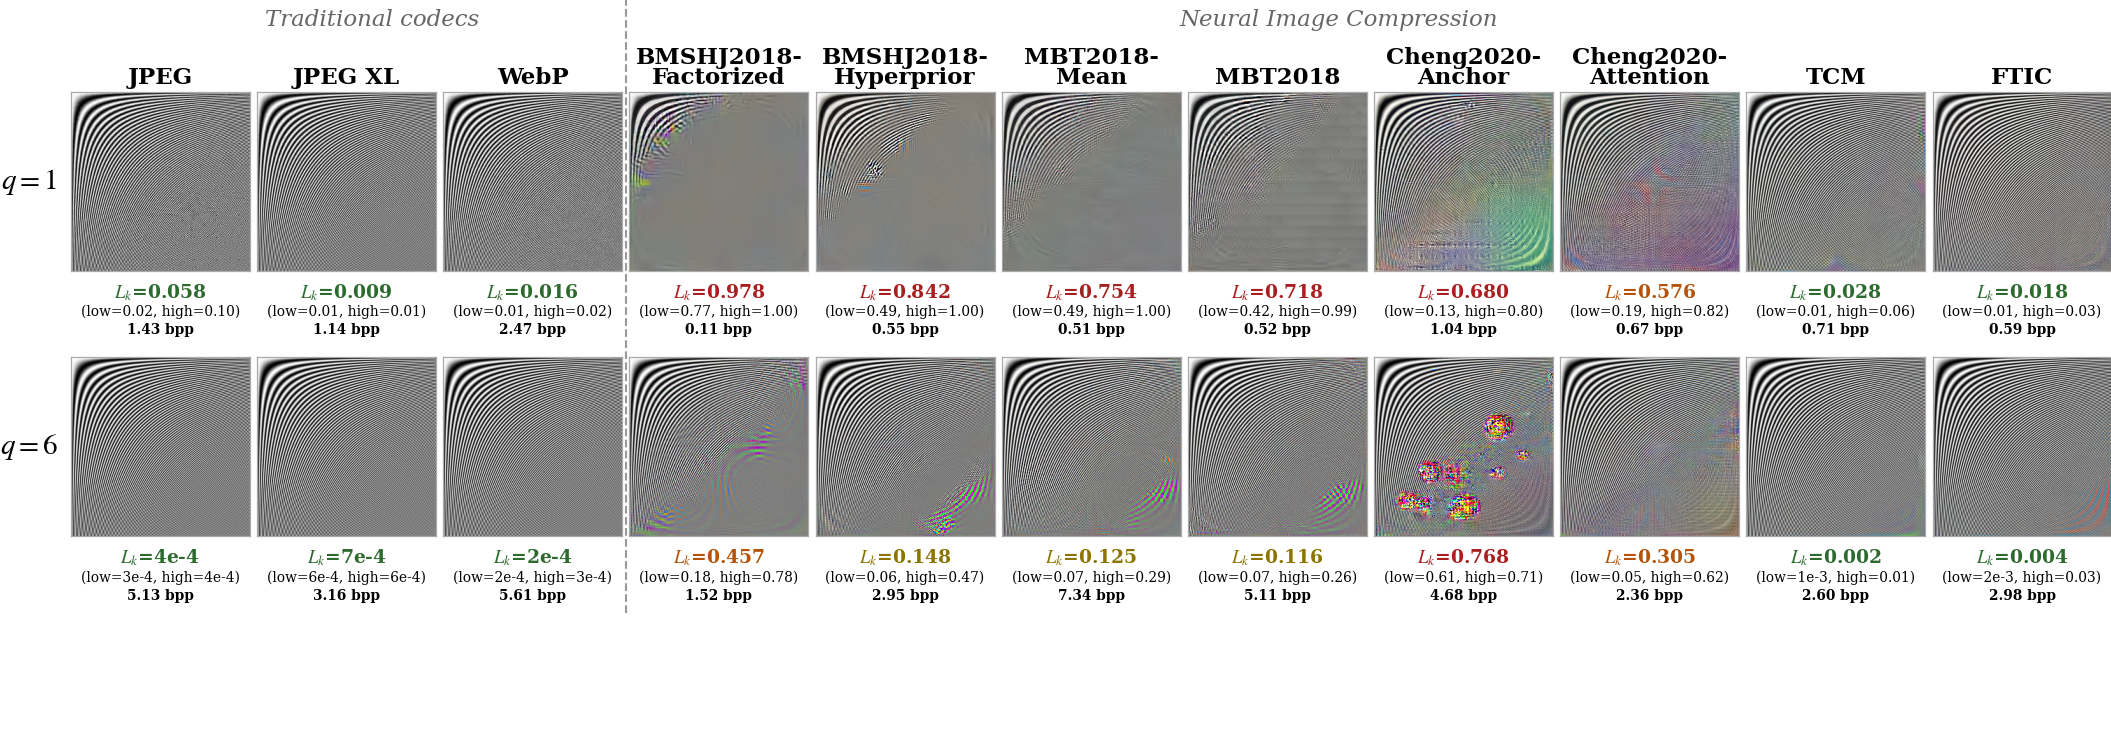

In [18]:
# Load pre-computed metrics for annotation
csv_256 = RESULTS / 'leakage_vs_bpp' / 'scan_leakage_vs_bpp_256.csv'
if not csv_256.exists():
    print('Run: python scripts/run_benchmark.py --size 256 --quality-sweep')
else:
    df256 = pd.read_csv(csv_256)
    print('Available models:', df256['model'].unique().tolist())

# Display pre-built figure (PNG renders in Jupyter; PDF does not)
from IPython.display import Image as IPImage, display as ipdisplay
prebuilt_png = Path('../paper/figures/fig3_dct_response_grid.png')
prebuilt_pdf = Path('../paper/figures/fig3_dct_response_grid.pdf')

if prebuilt_png.exists():
    ipdisplay(IPImage(filename=str(prebuilt_png), width=2100))
elif prebuilt_pdf.exists():
    print(f'PDF at {prebuilt_pdf} — convert to PNG for inline display.')
    print('Run: python scripts/plot_fig3_grid.py --from-csv')
else:
    print('No pre-built figure. Run: python scripts/plot_fig3_grid.py --live')

---
## Fig. 4 — Median Leakage vs Quality (Cheng2020 family, multiple sizes)

**Settings:** `cheng2020-anchor`, `cheng2020-attn`, q=1–6, sizes={64,128,256,512,1024}

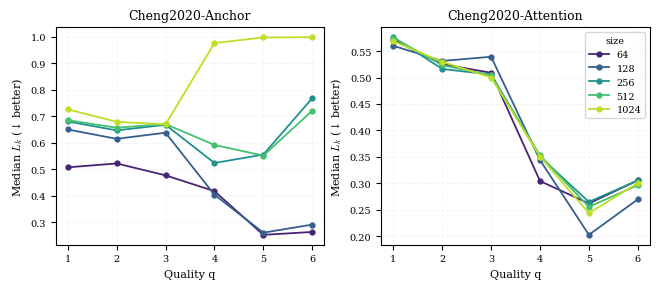

Fig. 4a saved.


In [5]:
df_all = pd.read_csv(RESULTS / 'all_metrics_summary.csv')

MODELS_FIG4 = ['cheng2020-anchor', 'cheng2020-attn']
SIZES_FIG4  = ['64x64', '128x128', '256x256', '512x512', '1024x1024']
SIZE_LABELS = ['64', '128', '256', '512', '1024']
QUALITIES   = [1, 2, 3, 4, 5, 6]
SIZE_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(SIZES_FIG4)))

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8), sharey=False)

for ax, model_id in zip(axes, MODELS_FIG4):
    sub = df_all[df_all['Model'] == model_id]
    for si, (sz, lbl, col) in enumerate(zip(SIZES_FIG4, SIZE_LABELS, SIZE_COLORS)):
        s = sub[sub['Size'] == sz].sort_values('q')
        if not s.empty:
            ax.plot(s['q'], s['L_k'], 'o-', color=col, markersize=3.5, lw=1.3, label=lbl)
    ax.set_xticks(QUALITIES)
    ax.set_xlabel('Quality q', fontsize=8)
    ax.set_ylabel(r'Median $L_k$ (↓ better)', fontsize=8)
    ax.set_title(LABELS.get(model_id, model_id), fontsize=9)
    ax.grid(True, ls=':', lw=0.4, alpha=0.4)
    ax.tick_params(labelsize=7)

axes[1].legend(title='size', fontsize=7, title_fontsize=7)
plt.tight_layout(pad=0.4)
plt.savefig(OUT / 'fig4_leakage_vs_quality.pdf', bbox_inches='tight')
plt.show()
print('Fig. 4a saved.')

---
## Fig. 5 — Rate–Leakage Comparison at 256×256

**Settings:** all codecs, full quality sweep, size=**256×256**

> Data: `results/leakage_vs_bpp/scan_leakage_vs_bpp_256.csv`  
> Generate: `python scripts/run_benchmark.py --size 256 --quality-sweep`

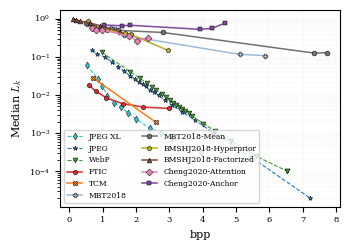

Fig. 5 saved.


In [6]:
csv = RESULTS / 'leakage_vs_bpp' / 'scan_leakage_vs_bpp_256.csv'
if not csv.exists():
    print('Missing data. Run: python scripts/run_benchmark.py --size 256 --quality-sweep')
else:
    df = pd.read_csv(csv)
    ORDER = ['jpegxl', 'jpeg', 'webp', 'ftic', 'tcm',
             'mbt2018', 'mbt2018-mean', 'bmshj2018-hyperprior',
             'bmshj2018-factorized', 'cheng2020-attn', 'cheng2020-anchor']

    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for name in ORDER:
        grp = df[df['model'] == name].sort_values('bpp')
        if grp.empty:
            continue
        ls = '--' if name in TRADITIONAL else '-'
        lw = 0.8 if name in TRADITIONAL else 1.1
        ax.semilogy(grp['bpp'], grp['L_k'], ls,
                    color=COLORS.get(name, 'gray'), marker=MARKERS.get(name, 'o'),
                    markersize=3.5, markeredgecolor='black', markeredgewidth=0.35,
                    lw=lw, label=LABELS.get(name, name))

    ax.set_xlabel('bpp', fontsize=8)
    ax.set_ylabel(r'Median $L_k$', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(True, which='both', ls=':', lw=0.3, alpha=0.5)
    ax.legend(fontsize=5.5, ncol=2)
    fig.tight_layout(pad=0.4)
    fig.savefig(OUT / 'fig5_leakage_vs_bpp_256.pdf', bbox_inches='tight')
    plt.show()
    print('Fig. 5 saved.')

---
## Fig. S1 — Directional Leakage Anisotropy

**Settings:** size=**512×512**, matched ≈2.5 bpp (JPEG q=43, WebP q=70, JXL d=2.5), angles: 0°–90°

> Generate: `python scripts/run_directional.py --size 512 --matched-bpp`

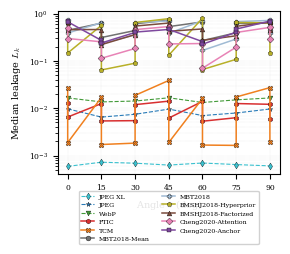

Fig. S1 saved.


In [14]:
csv_dir = RESULTS / 'directional' / 'directional_leakage.csv'
if not csv_dir.exists():
    print('Missing data. Run: python scripts/run_directional.py')
else:
    df_dir = pd.read_csv(csv_dir)
    # Paper Fig. S1: matched-bpp runs at 512×512 only
    df_dir = df_dir[(df_dir['size'] == '512x512') & (df_dir['matched_bpp'] == 1)]
    if df_dir.empty:
        # Fallback: all 512x512 data (one row per model per angle)
        df_dir = pd.read_csv(csv_dir)
        df_dir = df_dir[df_dir['size'] == '512x512']
        df_dir = df_dir.sort_values('matched_bpp', ascending=False).drop_duplicates(
            subset=['model', 'angle_deg'], keep='first')
    ANGLES = sorted(df_dir['angle_deg'].unique())

    # Plot order: traditional first (dashed), then NIC (solid)
    ORDER = ['jpegxl', 'jpeg', 'webp',
             'ftic', 'tcm', 'mbt2018-mean', 'mbt2018',
             'bmshj2018-hyperprior', 'bmshj2018-factorized',
             'cheng2020-attn', 'cheng2020-anchor']

    fig, ax = plt.subplots(figsize=(2.8, 2.6))
    for name in ORDER:
        sub = df_dir[df_dir['model'] == name].sort_values('angle_deg')
        if sub.empty:
            continue
        ls = '--' if name in TRADITIONAL else '-'
        ax.plot(sub['angle_deg'], sub['L_k'], ls,
                color=COLORS.get(name, 'gray'), marker=MARKERS.get(name, 'o'),
                markersize=3.5, markeredgecolor='black', markeredgewidth=0.25,
                lw=0.8 if name in TRADITIONAL else 1.1,
                label=LABELS.get(name, name))

    ax.set_yscale('log')
    ax.set_xlabel(r'Angle $\theta$ (deg)', fontsize=7)
    ax.set_ylabel(r'Median leakage $L_k$', fontsize=7)
    ax.set_xticks(ANGLES)
    ax.tick_params(labelsize=5.5)
    ax.grid(True, ls=':', lw=0.3, alpha=0.5, which='both')
    ax.legend(fontsize=4.5, ncol=2, loc='lower center',
              bbox_to_anchor=(0.5, -0.45), framealpha=0.9)
    fig.tight_layout(pad=0.4)
    fig.subplots_adjust(bottom=0.35)
    fig.savefig(OUT / 'figS1_directional_leakage.pdf', bbox_inches='tight')
    plt.show()
    print('Fig. S1 saved.')

---
## Fig. S3 — Fine-Tuning Result at 1024×1024

**Settings:** `cheng2020-anchor`, q=6, size=**1024×1024**, 900 steps, Adam lr=1e-4

> Generate: `python scripts/run_finetune.py --size 1024 --steps 900`

In [9]:
# Check if pre-built finetune figure exists
ft_pdf = OUT / 'finetune_cheng2020-anchor_1024_q6.pdf'
if ft_pdf.exists():
    print(f'Found: {ft_pdf}')
else:
    print('Run: python scripts/run_finetune.py --size 1024 --steps 900')
    print('For quick demo (128×128):')
    print('    python scripts/run_finetune.py --size 128 --steps 200')

Run: python scripts/run_finetune.py --size 1024 --steps 900
For quick demo (128×128):
    python scripts/run_finetune.py --size 128 --steps 200


---
## Table I — Codec Evaluation on Kodak (Spectral Leakage Coupling)

**Settings:** 24 Kodak images, highest quality (q=6), DCT size=**512×512**, N_b=512 radial bins

> Generate: `python scripts/run_kodak_eval.py --kodak-dir data/kodak`

In [12]:
kodak_csv = RESULTS / 'kodak_eval' / 'kodak_per_image.csv'
if kodak_csv.exists():
    df_kodak = pd.read_csv(kodak_csv)
    clean = df_kodak[df_kodak['distortion'] == 'codec_clean']
    agg = clean.groupby('model').agg(
        mean_psnr=('psnr', 'mean'),
        mean_Le=('Le', 'mean'),
        mean_rho_bar=('rho_bar', 'mean'),
    ).round(5)
    print('Table I — Spectral Leakage Coupling on Kodak (codec_clean):')
    print(agg.sort_values('mean_Le', ascending=False).to_string())

    # Add perceptual metrics if available
    perc_csv = RESULTS / 'kodak_eval' / 'perceptual_metrics.csv'
    if perc_csv.exists():
        df_perc = pd.read_csv(perc_csv)
        perc_agg = df_perc.groupby('model')[['psnr', 'ms_ssim', 'lpips']].mean().round(4)
        print('\nPerceptual metrics (from q=6 Kodak):')
        print(perc_agg.to_string())
else:
    print('Pre-computed Kodak results not found.')
    print('Run: python scripts/run_kodak_eval.py --kodak-dir data/kodak\n')
    print('Paper Table I data:')
    data = {
        'Codec': ['BMSHJ2018-Fact.', 'Cheng2020-Attn', 'Cheng2020-Anchor',
                  'MBT2018', 'BMSHJ2018-HP', 'MBT2018-Mean',
                  'FTIC', 'TCM', 'JPEG XL', 'JPEG', 'WebP'],
        'L_k':   [0.455, 0.296, 0.720, 0.115, 0.146, 0.116, 0.005, 0.002, 5.9e-4, 3.6e-4, 2.4e-4],
        'PSNR':  [35.38, 36.68, 36.76, 37.07, 36.74, 36.91, 37.90, 38.04, 34.05,  32.14,  34.48],
        'Le':    [0.187, 0.157, 0.148, 0.099, 0.097, 0.088, 0.017, 0.004, 1.2e-4, 9.7e-5, 4.9e-5],
        'Le/rho':[0.94,  0.92,  0.87,  0.62,  0.59,  0.55,  0.12,  0.03,  5.2e-4, 3.2e-4, 2.2e-4],
    }
    print(pd.DataFrame(data).to_string(index=False))

Table I — Spectral Leakage Coupling on Kodak (codec_clean):
                      mean_psnr  mean_Le  mean_rho_bar
model                                                 
bmshj2018-factorized   35.38080  0.18733       0.19855
cheng2020-attn         36.67645  0.15722       0.17098
cheng2020-anchor       36.76078  0.14778       0.16940
mbt2018                37.07062  0.09855       0.15814
bmshj2018-hyperprior   36.74315  0.09653       0.16481
mbt2018-mean           36.91052  0.08839       0.16094
ftic                   37.90374  0.01683       0.14032
tcm                    38.04430  0.00385       0.13666
jpegxl                 41.03789  0.00004       0.08781
jpeg                   42.30123  0.00003       0.11104
webp                   41.65980  0.00002       0.07728

Perceptual metrics (from q=6 Kodak):
                         psnr  ms_ssim   lpips
model                                         
bmshj2018-factorized  35.3808   0.9879  0.0860
bmshj2018-hyperprior  36.7432   0.9892  0.0846

---
## All Five Metrics: Band-wise Summary

Heatmap of all 5 metrics across all models, showing low / mid / high frequency bands.

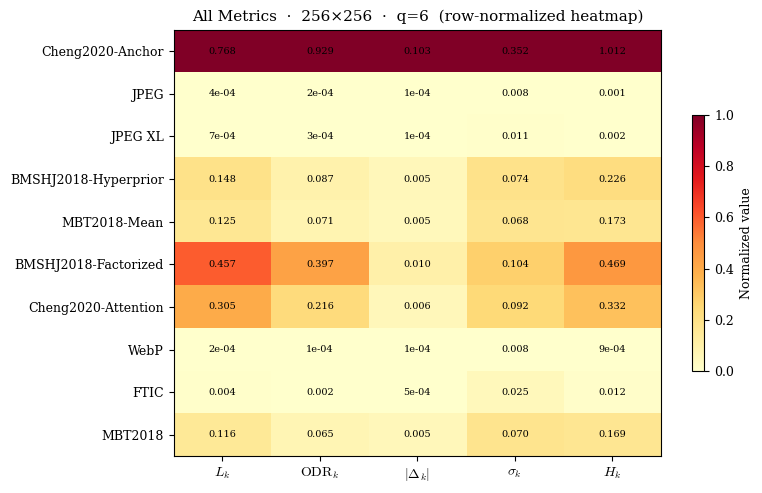

In [13]:
from matplotlib.colors import Normalize

df_all = pd.read_csv(RESULTS / 'all_metrics_summary.csv')
# Take q=6, size=256
df_q6 = df_all[(df_all.get('q', pd.Series(dtype=float)) == 6) & (df_all['Size'] == '256x256')]
if df_q6.empty:
    df_q6 = df_all[df_all['Size'] == '256x256'].sort_values('q', ascending=False).groupby('Model').first().reset_index()

METRIC_COLS = ['L_k', 'ODR_k', '|Delta_c_k|', 's_k', 'H_k_bits']
METRIC_LABELS = [r'$L_k$', r'$\mathrm{ODR}_k$', r'$|\Delta_k|$', r'$\sigma_k$', r'$H_k$']

avail_cols = [c for c in METRIC_COLS if c in df_q6.columns]
avail_labels = [METRIC_LABELS[METRIC_COLS.index(c)] for c in avail_cols]

if avail_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    mat = df_q6.set_index('Model')[avail_cols].values.astype(float)
    model_names = [LABELS.get(m, m) for m in df_q6['Model'].tolist()]
    # Normalize each column to [0,1] for comparison
    mat_norm = (mat - mat.min(axis=0)) / (mat.max(axis=0) - mat.min(axis=0) + 1e-12)
    im = ax.imshow(mat_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(avail_cols))); ax.set_xticklabels(avail_labels, fontsize=10)
    ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=9)
    for i in range(len(model_names)):
        for j in range(len(avail_cols)):
            v = mat[i, j]
            ax.text(j, i, f'{v:.3f}' if v >= 0.001 else f'{v:.0e}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.6, label='Normalized value')
    ax.set_title('All Metrics  ·  256×256  ·  q=6  (row-normalized heatmap)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / 'all_metrics_heatmap.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Metric columns not found. Run full benchmark first.')